In [203]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pygments.lexer import default
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler


RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [204]:
df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


1️⃣ Identifying the Prediction Target

The target variable is Cloumn "y", this is a binary variable that represents whether the client
subscribed or not to the term deposit and that is what we are trying to predict. Other variables like Duration(The time the call lasted) or poutcome(the outcome of the previous campaign), these are tricky variables, i could consider the time of the call duration and say, if the call lasted a lot than that means something positive, but since we are predicting with the information available at the time of contact and call duration is only know after the call then it cant be used. And with poutcome it can also be a bit confusing since i see the "outcome" part but its not the outcome we are looking for its only information on a previous campaign, not really usefull for this. Specially since most didnt participate in a previous campaign.


## **2️⃣ Data Loading and Exploration**



#### Inspection of structure:

In [205]:
df.info()
print("The shape is:",df.shape)
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [206]:
df.describe(include=['object', 'string'])

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


#### Categorical vs Numerical var

In [207]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
numerical_cols = df.select_dtypes(exclude=['object', 'string']).columns

categorical_cols, numerical_cols # We have

(Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
        'month', 'day_of_week', 'poutcome', 'y'],
       dtype='str'),
 Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
        'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
       dtype='str'))

Here we separate our categorical and numerical and see we have 10 numerical variables and 11 (including the target) categorical variables

##### Possible class imbalance? **Below** we can see that there is a major class imbalance since our predicted variable "y" is binary yes or no, the amount of "no" overpowers the "yes" by over 3000 counts. We should consider this class imbalance for the future since our classifier could achive a very high accuracy while failing to identify actual subscribers, we cant focus entirely on accuracy.

In [208]:
df['y'].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

#### Missing values

In [209]:
NaNs = df.isnull()
NaNs


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4115,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4116,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4117,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [210]:
NaNs.sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [211]:
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count}")

job: 39
marital: 11
education: 167
default: 803
housing: 105
loan: 105


for explicit we can see there is no missing values for numerical variables. The dataset uses "unknown" for its implicit missing values in categorical clumns, so we can check how many there are in each variable if they have any and treat them later.



#### **Visualization**


Numerical Plots:

In [212]:
df["pdays"].describe() # IMPORTANT NOTICE: looking at the pdays variable we see it has many 999 variables, wich probably means that hte person wasnt previously contacted, for now we are just going to consider it and later treat it as needed.

count    4119.000000
mean      960.422190
std       191.922786
min         0.000000
25%       999.000000
50%       999.000000
75%       999.000000
max       999.000000
Name: pdays, dtype: float64

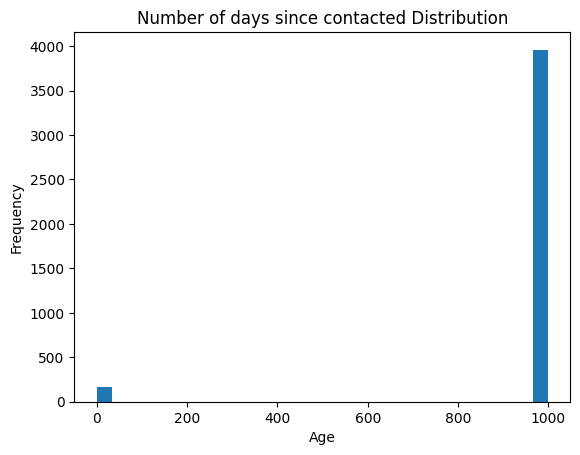

In [213]:
plt.hist(df['pdays'], bins=30)
plt.title("Number of days since contacted Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

In [214]:
df["duration"].describe() # And for the second one we will look at duration, to visualize the heavy skew


count    4119.000000
mean      256.788055
std       254.703736
min         0.000000
25%       103.000000
50%       181.000000
75%       317.000000
max      3643.000000
Name: duration, dtype: float64

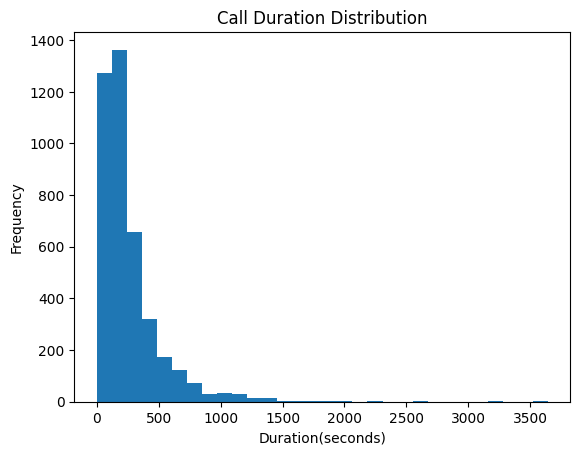

In [215]:
plt.hist(df['duration'], bins=30)
plt.title("Call Duration Distribution")
plt.xlabel("Duration(seconds)")
plt.ylabel("Frequency")
plt.show()

Categorical Plots


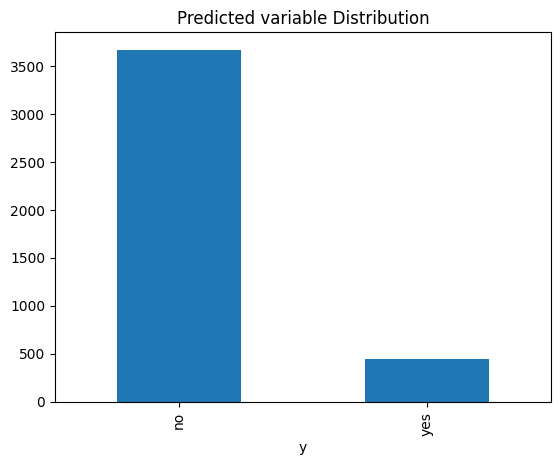

In [216]:
df['y'].value_counts().plot(kind='bar')
plt.title("Predicted variable Distribution")
plt.show()

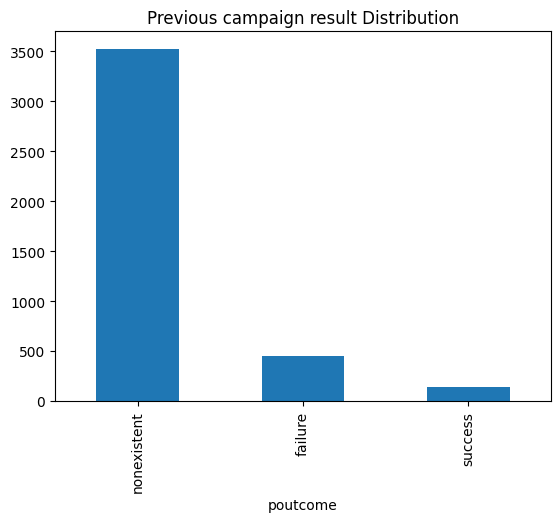

In [217]:
df['poutcome'].value_counts().plot(kind='bar')
plt.title("Previous campaign result Distribution")
plt.show()

#### **Requires special consideration: "Duration"**, as we previously knew and as we can now see, Duration is very heavily right skewed, and it is a variable that wasnt avaialbe at prediction time so we should pay attention to it in the future.


## **3️⃣ Data Splitting (Train / Validation / Test**

What split am i doing? Well, given the dataset contains over 40,000 observations wich is large and wollowing the class example which also had a large "dataset",im doing a 60/20/20 split, allocating 20% of the data to validation and test still results in more than 8,000 samples per subset. This size is sufficiently large to produce stable and reliable estimates of classification metrics, even under class imbalance. At the same time, retaining 60% for training ensures the model has enough data to learn any patterns.

In [218]:
X = df.drop('y', axis=1) # define x and y, X is every other variable
y = df['y'] #and y is our target variable

#### First we do our first split

In [219]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.40, # keeping 40% in a temporal set to later split into test/validation
    stratify=y, # we use stratisfy due to the class imbalance we previously mentioned, this way we keep the same proportion of yes/no in both splits
    random_state=RANDOM_STATE
)

#### Then we do the second split, for the temporary split wich now turns into 50% test and 50% validation


In [220]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,      # half of the 40% -> 20% overall
    stratify=y_temp,     #stratisfy on the already split target variable(y). we do this to maintsin class proportions between splits.
    random_state=RANDOM_STATE
)

Then we visualize the 3 sized to confirm splits where done correctly:


In [221]:
print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])


Train size: 2471
Validation size: 824
Test size: 824


And here we can confirm that the stratification worked adn it perserved the class balance we wheere worried about(with the code help of chatGPT)

In [222]:
print("\nTrain distribution:\n", y_train.value_counts(normalize=True))
print("\nValidation distribution:\n", y_val.value_counts(normalize=True))
print("\nTest distribution:\n", y_test.value_counts(normalize=True))


Train distribution:
 y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64

Validation distribution:
 y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

Test distribution:
 y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64


#### **Importance of splitting at this stage:**
We must split our dataset before performing any sort of preprocessing steps like scaling, imputation,encoding feature selection or class imbalance resampling information from the validation or test sets could become infuential in the training. For example Imputation before splitting could add distributional information from unseen data, and feature selection based on the full dataset could indirectly use test set correlations(which we dont want)

All these situations could lead to data leakage and would lead to overly positive performance when in reality it isnt, violating the principle of unbiased evaluation we see in lectures.

## **4️⃣ Missing Values Handling (fit on train only)**

In our data exploration stage we saw that we did not have any explicit NaNs(showing again for reference):

In [223]:
NaNs.sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

And for implicit missing values we also mentioned that we discovered:

There is a categorical "unkwnow" in some of the variables like job or education as we can see, with the full percentages on how much it takes in each variable (showing again for reference):


In [224]:
total_rows = len(df)

for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        percentage = unknown_count / total_rows * 100
        print(f"{col}: {unknown_count} ({percentage:.2f}%)")

job: 39 (0.95%)
marital: 11 (0.27%)
education: 167 (4.05%)
default: 803 (19.50%)
housing: 105 (2.55%)
loan: 105 (2.55%)


And we also discovered that there is a sentinel value for "pdays", after safeley assuming that 999 means never contacted we considered it to not be a real meassurment it its pretty much "encoded missingness" isntead of actual meassurments that require carful handling, here we can quantify it:

In [225]:
(df['pdays'] == 999).sum()

np.int64(3959)

In [226]:
(df['pdays'] == 999).mean() * 100

np.float64(96.11556202961884)

96% of the values in pdays distribution are 999.

Overall the proportion of missingness varies a lot across variables. In particular, the high proportion in "default" and "pdays" suggests that missingness itself may carry predictive information.

#### **Possible strategy:**

For the categorical variables containing "unknown" we will be treating it as a separate category instead of removing them or applying imputation. Removing them could discard useful information, and imputing the most frequent category may mask potential informative missingness. keeping "unknown" maintains the possibility that missingness itself carries predictive information. During one-hot encoding, "unknown" will naturally become its own binary feature, allowing the model to learn whether missingness carries any predictive information

For the "pdays" variable value 999 represents a sentinel code indicating that the client was not previously contacted, to help clean out the data and perserve the meaning of it and in order to avoid distortion during scaling, we will create an indicator variable called **pcontacted** equal to 1 if contacted or 0 if not contacted. we will then replace the value 999 with a missingvalue and impute it using median of pdays computed **on the training dataset only** median imputation was choosen because it is good with skewed distributions and prevents extreme values from influencing the imputation.

By adding the indicator variable prevents the model from getting confused and efficiently distinguish that if the indicator variable = 0(not contacted) the numeric pdays value becomes irrelevant but information is still perserved.

#### **What must be fit on train set only?:**
Well any operation we conduct that computed statistics from data (for example median for imputation) must be fitted using only the training set, this includes:
* Computing the median of pdays for imputation.
* Computing the most frequent value if categorical imputation were used.
* Computing scaling statistics (mean and standard deviation).

the learned parameters are then applied unchanged to the validation and test sets. Computing imputation values on the full dataset would introduce preprocessing leakage by adding distributional information on unseen data, leading to very positive evaluation on some data.

#### **Implementation:**
We first start by creating the indicator variable we previously discussed,

In [227]:
for X_ in [X_train, X_val, X_test]:
    X_["previously_contacted"] = (X_["pdays"] != 999).astype(int)

Secondly we will replace "pdays" 999 with NaN as mentioned:
never contacted = 999 has already been captured in new variable
Keeping 999 would affect later steps
creating NaNs now sets up for future imputation **(on training only)**

In [228]:
for X_ in [X_train, X_val, X_test]:
    X_.loc[X_["pdays"] == 999, "pdays"] = np.nan

The previous steps were done in all 3 datasets(splits) because if we only added it to training teh validation/test split would not have that feature and feature spaces would be different leading to the model breaking.

**Next** we will fit the median only on the train to maintain the validation and test hidden and avoid leakage

In [229]:
median_pdays = X_train["pdays"].median()
median_pdays

np.float64(4.0)

And finally we impute the NaNs of all three with the median gotten only from the train set.

In [230]:
for X_ in [X_train, X_val, X_test]:
    X_["pdays"] = X_["pdays"].fillna(median_pdays)

## **5️⃣  Encoding categorical Variables (fit on train only)**


In [231]:
trainCat_cols = X_train.select_dtypes(include=["object","string"]).columns

For the classifications, we can clearly see that the following variables are strictly nominal, 'job', 'marital', 'default', 'housing', 'loan', 'contact','poutcome', they are all straight forward and can be easily distinguished, but in the other hand we have:

some confusing variables that are: 'education' and 'month';

education: altough education is technically an ordinal variable since we know education levels have an order, illiterate --> basic.4y --> basic.6y --> basic.9y --> high.school --< professional.course --> university.degree, but enconding this variable as a ordinal numerical variable would treat that order as a linear relationship meaning there would be equal spacing between education levels not as a "series" that its supossed to be, so the best way to maintain some order would be to also treat it as a nominal variable and applying one.hot encoding.

month/day_of_week: were also a bit confusing, both have an order monday --> sunday and january --> december, but in the end they are cyclical, so after december comes january again, same with the week days, so its also better to treat it as a nominal variable and apply one-hot enconding since logistic regression is sensitive to linear structures in features, we need to maintain the ccycle.

Now, we will wirst create the one hot encoder, and fitting it on the train data only, to prevent any leakage

In [232]:
onehe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [233]:
onehe.fit(X_train[trainCat_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

Once we fitted on training only, we apply it to the rest of the splits(We transform them using the same already fitted encoder in order to maintain feature space consistent and in order to avoid leakage)

In [234]:
encoded_feature_names = onehe.get_feature_names_out(trainCat_cols)

In [235]:
X_train_cat = onehe.transform(X_train[trainCat_cols])
X_val_cat   = onehe.transform(X_val[trainCat_cols])
X_test_cat  = onehe.transform(X_test[trainCat_cols])

In [236]:
X_train_cat.shape, X_val_cat.shape, X_test_cat.shape #sanity check to see if the transformation happened correctly

((2471, 53), (824, 53), (824, 53))

In [237]:
[name for name in encoded_feature_names if "unknown" in name] # checking if unknown was encoded correctly and turned into its own feature and we see it did.

['job_unknown',
 'marital_unknown',
 'education_unknown',
 'default_unknown',
 'housing_unknown',
 'loan_unknown']

Now we re build our dataset with our newly accuired features.

In [238]:
numeric_cols = X_train.select_dtypes(exclude="object").columns # we first re-create our numeric col from train set.
numeric_cols

Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'previously_contacted'],
      dtype='str')

Then we create the new variables with the numeric columns only for each of the splits(we reset their index so it aligns correctly with the encoded df and it doesnt mess up the order)

Then we convert our encoded arrays into a DataFrame

Finally we combine both the encoded categorical and numeric into the df and let its now ready for modeling.

In [239]:
X_train_num = X_train[numeric_cols].reset_index(drop=True)
X_val_num   = X_val[numeric_cols].reset_index(drop=True)
X_test_num  = X_test[numeric_cols].reset_index(drop=True)


In [240]:
# Encoded categorical parts
X_train_cat_df = pd.DataFrame(X_train_cat, columns=encoded_feature_names).reset_index(drop=True)
X_val_cat_df   = pd.DataFrame(X_val_cat, columns=encoded_feature_names).reset_index(drop=True)
X_test_cat_df  = pd.DataFrame(X_test_cat, columns=encoded_feature_names).reset_index(drop=True)

In [241]:
# Combine numeric + categorical
X_train_encoded = pd.concat([X_train_num, X_train_cat_df], axis=1)
X_val_encoded   = pd.concat([X_val_num, X_val_cat_df], axis=1)
X_test_encoded  = pd.concat([X_test_num, X_test_cat_df], axis=1)

X_train_encoded.shape

(2471, 64)

#### **Final analysis;**

Dimensionality Change:

In [242]:
print("Before encoding:", X_train.shape)
print("After encoding:", X_train_encoded.shape)

Before encoding: (2471, 21)
After encoding: (2471, 64)


We can see that  before encoding we had 21 features and after applying the onehot encoding to the categorical variables we see that the numer of variables increased by 43 to 64, This increase occurs because each categorical variable with k distinct categories is transformed into k binary indicator variables. As a result, the dimensionality of the feature space expands.

Next for Interpretability of model coefficients:
Once we finished with one-hot encoding, each categorical level is represented as an independent binary feature, in logistic regression this allows the model to assign a separate coeficient to each category level. teh coefficient associated with a given binary feature shows the change in log-odds of the positive class when present, when the baseline was defined by the intercept  and other featured.

using one hotencoding  avoids adding a linear or equally spaced structure between categories. this helps a lot with interpretability by allowing the model to learncategory specific effects. however, one-hot encoding increases dimensionality(as seen) and could also introduce multicolinearity in dummy variables, but with regularized logistic regression it could be regularized.

Finally Decision boundries that could be represented:

Logistic regression defines a linear decision boundry in feature space. after one hot encoding, categorical variables are expanded into multiple binary dimensions(more feature space), altough the decision boundry remains linear, it now works on a higher dimensional space. this makes the model become more flexible allowing it to add distinct effects to different category levels without imposing artificial ordering constraints. But overall the decision boundry remains linear, meaning interactions between categories and nonlinear relationships are not explicitly modeled.

 ## **6️⃣ Feature Scaling (fit on train only)**


Now for scaling, we frist select what features we will scale, to do this we will only scale the numeric columns we havent touched(So excluding the encoded ones and previously_contacted which are already 1/0) so we scale the continuous numeric features we have, we check here:

In [243]:
# numeric columns from the original (pre-encoding) X_train
numeric_cols = X_train.select_dtypes(exclude="object").columns

# these are binary (0/1), so we don't scale them
binary_cols = ["previously_contacted"]

# columns to scale = numeric minus binary
scale_cols = [c for c in numeric_cols if c not in binary_cols]
scale_cols

['age',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'emp.var.rate',
 'cons.price.idx',
 'cons.conf.idx',
 'euribor3m',
 'nr.employed']

Now for our scalling method we are going to do standardization since logistic regression uses gradient based optimization and features on different scales cause uneven gradients. so standardisation makes features comparable (with mean0 and std 1). Once again we fit ON TRAIN ONLY since the scaler computes mean and std and these can only be learned from training, since like in the other, using other data would introduce leakage:

In [244]:
scaler = StandardScaler()

# fit ONLY on training data
scaler.fit(X_train_encoded[scale_cols])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


Now we apply the fitted scaling to the rest of the data, without touching what we are not supossed to.

In [245]:
# Apply scaling using the fitted scaler
X_train_encoded[scale_cols] = scaler.transform(X_train_encoded[scale_cols])
X_val_encoded[scale_cols]   = scaler.transform(X_val_encoded[scale_cols])
X_test_encoded[scale_cols]  = scaler.transform(X_test_encoded[scale_cols])

In [246]:
X_train_encoded[scale_cols].describe().T[['mean', 'std']].head()

,mean,std
age,-1.811582e-16,1.000202
duration,8.339028e-17,1.000202
campaign,-4.744620e-17,1.000202
pdays,2.674240e-16,1.000202
previous,-1.150211e-17,1.000202


As we can see the scalling worked efficiently ( mean close to 0 and std close to 1), this scalling efficiently improves gradient-based optimization making it more stable and faster convergance. the magnitude and comparability of model coefficients making them more comparable across all features and since we used the regularization Ridge (L2) penalty which treats features more fairly when they’re on the same scale

## **7️⃣ Feature Selection (fit on train only)**

First we indentify our low variance features by computing it only on our train split, the ones we consider low variance are based on it getting as close to zero as possible or constant 0, this is to be conservative and try keeping rare but possibly meaningful categories, also L2 regularization already shrinks rare features and can handle them.

In [247]:
feature_variances = X_train_encoded.var()
low_variance = feature_variances.sort_values().head(15)
low_variance

education_illiterate    0.000405
default_yes             0.000405
marital_unknown         0.002826
month_dec               0.006436
job_unknown             0.008032
month_mar               0.010019
month_sep               0.015540
job_student             0.018277
month_oct               0.019056
loan_unknown            0.021772
housing_unknown         0.021772
job_unemployed          0.022545
job_housemaid           0.028682
poutcome_success        0.034735
job_entrepreneur        0.035860
dtype: float64

We can see that non of the variables really get close to 0, the lowest is 0.000405, which is about 2% which is low but doesnt mean we should remove them, removing them could remove signal, so we keep all based on variance, now we check highly correlated numerical features:

 Logistic regresion assumes low multicolinearity and correlation close to 1 implies almost linear dependence, so we define “high correlation” to those with a coefficient greater than 0.9. This threshold is chosen to identify near-redundant features while avoiding unnecessary removal of slightly correlated variables. Since logistic regression with L2 regularization can tolerate moderate correlations, we adopt a conservative criterion that targets only very strong linear dependencies.

In [248]:
corr_matrix = X_train_encoded[scale_cols].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = upper.stack().sort_values(ascending=False)

high_corr_pairs.head(10)

emp.var.rate    euribor3m         0.970013
euribor3m       nr.employed       0.941699
emp.var.rate    nr.employed       0.896018
                cons.price.idx    0.757662
cons.price.idx  euribor3m         0.656884
previous        nr.employed       0.520717
cons.price.idx  nr.employed       0.470515
previous        euribor3m         0.469319
                emp.var.rate      0.428931
cons.conf.idx   euribor3m         0.264169
dtype: float64

We see we have 2 very highly correlated variables, they are part of the macroeconomic indicators,


emp.var.rate  – euribor3m       0.970013

euribor3m     – nr.employed     0.941699

We check to see which one and why we should remove it, we do an average correlation strenght to decide:


In [249]:
corr_matrix = X_train_encoded[scale_cols].corr().abs()
corr_matrix[['emp.var.rate','euribor3m']].mean()

emp.var.rate    0.457289
euribor3m       0.466012
dtype: float64

In [250]:
low_var_001 = feature_variances[feature_variances < 0.01]
low_var_001.sort_values()

education_illiterate    0.000405
default_yes             0.000405
marital_unknown         0.002826
month_dec               0.006436
job_unknown             0.008032
dtype: float64

We see that euribor3m has the strongest linear relationship with emp.var.rate, and this violates the assumption of low feature independence and may lead to unstable coefficent estimates. TO reduce redundancy but still perserving economic info we will remove euribor3m as it is the one with the strongest correlation to other macro indicators. this decision remove possible multicolinearity and improves coefficient stability.

In [254]:
X_train_encoded = X_train_encoded.drop(columns=["euribor3m"])
X_val_encoded   = X_val_encoded.drop(columns=["euribor3m"])
X_test_encoded  = X_test_encoded.drop(columns=["euribor3m"])

And finally the feature that we discussed at the begining that could be very problematic because of temporal leakage is duration, since this varaible represents how long the call lasted and this is information know only after the call happened not available at prediction time, so the model would result in unrealistically optimistic model performance. Therefore, duration is removed from all datasets to ensure that the model reflects realistic deployment conditions.

In [251]:
X_train_encoded = X_train_encoded.drop(columns=["duration"])
X_val_encoded   = X_val_encoded.drop(columns=["duration"])
X_test_encoded  = X_test_encoded.drop(columns=["duration"])

In [256]:
X_train_encoded.shape, X_val_encoded.shape, X_test_encoded.shape

((2471, 62), (824, 62), (824, 62))

## **8️⃣ Address Class Imbalance (TRAIN ONLY)**

## **9️⃣ Train Logistic Regression + Evaluate**